In [ ]:
!nvidia-smi

Sun Oct  6 00:33:31 2024       
+---------------------------------------------------------------------------------------+
| NVIDIA-SMI 535.104.05             Driver Version: 535.104.05   CUDA Version: 12.2     |
|-----------------------------------------+----------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id        Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |         Memory-Usage | GPU-Util  Compute M. |
|                                         |                      |               MIG M. |
|=========================================+======================+======================|
|   0  Tesla T4                       Off | 00000000:00:04.0 Off |                    0 |
| N/A   34C    P8               9W /  70W |      0MiB / 15360MiB |      0%      Default |
|                                         |                      |                  N/A |
+-----------------------------------------+----------------------+--

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision.transforms.functional as F
import torchvision
from torchvision import transforms
import numpy as np
import pandas as pd
from tqdm import tqdm
from matplotlib import image
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import cv2
from fastai.vision.all import *
import os
import os.path
import json
from PIL import Image
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from typing import Any, Callable, Optional, Tuple, List

In [ ]:
!pip install fastai --upgrade
#!pip3 install numpy==1.17.4

In [ ]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'

In [ ]:
def count_parameters(model):
    params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    return params/1000000

Here's a Python implementation of the MBConv block with a Convolutional Block Attention Module (CBAM) integrated, using PyTorch. We'll first define the CBAM module, and then we'll modify the MBConv block to include CBAM.

### 1. Define CBAM Module

In [ ]:
# ----------------------- CBAM Channel Attention Module ------------------------

class ChannelAttention(nn.Module):
    def __init__(self, in_channels, reduction=16):
        super(ChannelAttention, self).__init__()
        self.avg_pool = nn.AdaptiveAvgPool2d(1)
        self.max_pool = nn.AdaptiveMaxPool2d(1)

        self.fc = nn.Sequential(
            nn.Conv2d(in_channels, in_channels // reduction, 1, bias=False),
            nn.ReLU(),
            nn.Conv2d(in_channels // reduction, in_channels, 1, bias=False)
        )

        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        avg_out = self.fc(self.avg_pool(x))
        max_out = self.fc(self.max_pool(x))
        out = avg_out + max_out
        return self.sigmoid(out) * x

# ----------------------- CBAM Spatial Attention Module ------------------------

class SpatialAttention(nn.Module):
    def __init__(self, kernel_size=7):
        super(SpatialAttention, self).__init__()
        assert kernel_size in (3, 7), 'kernel size must be 3 or 7'
        padding = 3 if kernel_size == 7 else 1
        self.conv = nn.Conv2d(2, 1, kernel_size, padding=padding, bias=False)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        avg_out = torch.mean(x, dim=1, keepdim=True)
        max_out, _ = torch.max(x, dim=1, keepdim=True)
        x = torch.cat([avg_out, max_out], dim=1)
        x = self.conv(x)
        return self.sigmoid(x) * x

# ----------------- CBAM Module (Channel + Spatial Attention) ------------------

class CBAM(nn.Module):
    def __init__(self, in_channels, reduction=16, kernel_size=7):
        super(CBAM, self).__init__()
        self.channel_attention = ChannelAttention(in_channels, reduction=reduction)
        self.spatial_attention = SpatialAttention(kernel_size=kernel_size)

    def forward(self, x):
        x = self.channel_attention(x)
        x = self.spatial_attention(x)
        return x


In [ ]:
# Example usage ---> test the CBAM Module
in_channels = 32

cbam_block = CBAM(in_channels)
input_tensor = torch.randn(1, in_channels, 224, 224)  # Batch size 1, 32 channels, 224x224 input size
output = cbam_block(input_tensor)
print(output.shape)

torch.Size([1, 1, 224, 224])


### 2. Define MBConv with CBAM



In [ ]:
# MBConv is based on inverted residuals with depthwise separable convolutions.
# We will add the CBAM block at the end of the MBConv block.

class MBConvBlockWithCBAM(nn.Module):
    def __init__(self, in_channels, out_channels, expand_ratio, stride, reduction=16, kernel_size=7):
        super(MBConvBlockWithCBAM, self).__init__()

        hidden_dim = in_channels * expand_ratio
        self.stride = stride

        # 1x1 pointwise conv (if expand ratio != 1)
        self.expand_conv = nn.Conv2d(in_channels, hidden_dim, 1, bias=False) if expand_ratio != 1 else None
        self.bn0 = nn.BatchNorm2d(hidden_dim) if expand_ratio != 1 else None

        # Depthwise 3x3 conv
        self.depthwise_conv = nn.Conv2d(hidden_dim, hidden_dim, kernel_size=3, stride=stride, padding=1, groups=hidden_dim, bias=False)
        self.bn1 = nn.BatchNorm2d(hidden_dim)

        # Squeeze-and-excitation (SE)
        self.se = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),
            nn.Conv2d(hidden_dim, hidden_dim // 4, 1),
            nn.ReLU(inplace=True),
            nn.Conv2d(hidden_dim // 4, hidden_dim, 1),
            nn.Sigmoid()
        )

        # 1x1 pointwise conv to project back to out_channels
        self.project_conv = nn.Conv2d(hidden_dim, out_channels, 1, bias=False)
        self.bn2 = nn.BatchNorm2d(out_channels)

        # CBAM Module
        self.cbam = CBAM(out_channels, reduction=reduction, kernel_size=kernel_size)

        # Skip connection
        self.use_residual = (in_channels == out_channels and stride == 1)

    def forward(self, x):
        residual = x

        # Expand
        if self.expand_conv:
            x = self.expand_conv(x)
            x = self.bn0(x)
            x = F.relu6(x)

        # Depthwise Convolution
        x = self.depthwise_conv(x)
        x = self.bn1(x)
        x = F.relu6(x)

        # Squeeze-and-Excitation
        x_se = self.se(x)
        x = x * x_se

        # Project back to out_channels
        x = self.project_conv(x)
        x = self.bn2(x)

        # Apply CBAM Attention
        x = self.cbam(x)

        # Residual Connection
        if self.use_residual:
            x = x + residual

        return x

In [ ]:
# You can now use the `MBConvBlockWithCBAM` in your custom EfficientNet B0 architecture where necessary.
# You'd replace the typical MBConv blocks with this new block to incorporate CBAM attention.

# Example usage ---> test the MBConvBlockWithCBAM Module
in_channels = 32
out_channels = 16
expand_ratio = 6
stride = 1

mbconv_cbam_block = MBConvBlockWithCBAM(in_channels, out_channels, expand_ratio, stride)
input_tensor = torch.randn(1, in_channels, 224, 224)  # Batch size 1, 32 channels, 224x224 input size
output = mbconv_cbam_block(input_tensor)
print(output.shape)


torch.Size([1, 1, 224, 224])


### 3. Using MBConv Block with CBAM in EfficientNet




In [ ]:
# Below is the Python code to implement a custom `EfficientNet B0` architecture using the `MBConvBlockWithCBAM`.
# We'll first define the EfficientNet B0 architecture and replace the standard `MBConv` blocks
# with the custom `MBConvBlockWithCBAM` block.


### 2. **EfficientNet B0 Architecture**

# Now, we'll build the full custom EfficientNet B0 model using the new MBConv block with CBAM.

#### Architecture Layout:
# EfficientNet uses a compound scaling method to balance depth, width, and resolution.
# EfficientNet-B0 is based on the following architecture block:

#| Stage | Operator        | Repeats | In | Out | SE | Stride |
#|-------|-----------------|---------|----|-----|----|--------|
#| 1     | Conv3x3         | 1       | 3  | 32  | -  | 2      |
#| 2     | MBConv1, k3x3   | 1       | 32 | 16  | -  | 1      |
#| 3     | MBConv6, k3x3   | 2       | 16 | 24  | -  | 2      |
#| 4     | MBConv6, k5x5   | 2       | 24 | 40  | SE | 2      |
#| 5     | MBConv6, k3x3   | 3       | 40 | 80  | -  | 2      |
#| 6     | MBConv6, k5x5   | 3       | 80 | 112 | SE | 1      |
#| 7     | MBConv6, k5x5   | 4       | 112| 192 | SE | 2      |
#| 8     | MBConv6, k3x3   | 1       | 192| 320 | SE | 1      |

# We'll implement the architecture using PyTorch by replacing the MBConv blocks with `MBConvBlockWithCBAM`.
        # Blocks configuration: (expand_ratio, channels, repeats, stride, kernel_size)
        #self.blocks = nn.ModuleList([
         #   MBConvBlock(32, 16, 1, 1, 3),  # stage 1

class EfficientNetB0CBAM(nn.Module):
    def __init__(self, num_classes=1000):
        super(EfficientNetB0CBAM, self).__init__()

        # Stage 1: Initial 3x3 Conv Layer
        self.conv1 = nn.Conv2d(3, 32, kernel_size=3, stride=2, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(32)

        # Stage 2: MBConv1, k3x3
        self.mbconv1 = MBConvBlockWithCBAM(32, 16, expand_ratio=1, stride=1)

        # Stage 3: MBConv6, k3x3, stride 2
        self.mbconv2 = nn.Sequential(
            MBConvBlockWithCBAM(16, 24, expand_ratio=6, stride=2),
            MBConvBlockWithCBAM(24, 24, expand_ratio=6, stride=1)
        )

        # Stage 4: MBConv6, k5x5, SE, stride 2
        self.mbconv3 = nn.Sequential(
            MBConvBlockWithCBAM(24, 40, expand_ratio=6, stride=2),
            MBConvBlockWithCBAM(40, 40, expand_ratio=6, stride=1)
        )

        # Stage 5: MBConv6, k3x3, stride 2
        self.mbconv4 = nn.Sequential(
            MBConvBlockWithCBAM(40, 80, expand_ratio=6, stride=2),
            MBConvBlockWithCBAM(80, 80, expand_ratio=6, stride=1),
            MBConvBlockWithCBAM(80, 80, expand_ratio=6, stride=1)
        )

        # Stage 6: MBConv6, k5x5, SE, stride 1
        self.mbconv5 = nn.Sequential(
            MBConvBlockWithCBAM(80, 112, expand_ratio=6, stride=1),
            MBConvBlockWithCBAM(112, 112, expand_ratio=6, stride=1),
            MBConvBlockWithCBAM(112, 112, expand_ratio=6, stride=1)
        )

        # Stage 7: MBConv6, k5x5, SE, stride 2
        self.mbconv6 = nn.Sequential(
            MBConvBlockWithCBAM(112, 192, expand_ratio=6, stride=2),
            MBConvBlockWithCBAM(192, 192, expand_ratio=6, stride=1),
            MBConvBlockWithCBAM(192, 192, expand_ratio=6, stride=1),
            MBConvBlockWithCBAM(192, 192, expand_ratio=6, stride=1)
        )

        # Stage 8: MBConv6, k3x3, SE, stride 1
        self.mbconv7 = MBConvBlockWithCBAM(192, 320, expand_ratio=6, stride=1)

        # Final Conv Layer and Pooling
        self.conv2 = nn.Conv2d(320, 1280, kernel_size=1, bias=False)
        self.bn2 = nn.BatchNorm2d(1280)
        self.fc = nn.Linear(1280, num_classes)

    def forward(self, x):
        # Forward pass through each stage
        x = F.relu6(self.bn1(self.conv1(x)))
        x = self.mbconv1(x)
        x = self.mbconv2(x)
        x = self.mbconv3(x)
        x = self.mbconv4(x)
        x = self.mbconv5(x)
        x = self.mbconv6(x)
        x = self.mbconv7(x)
        x = F.relu6(self.bn2(self.conv2(x)))

        # Global Average Pooling
        x = F.adaptive_avg_pool2d(x, 1).view(x.size(0), -1)
        x = self.fc(x)
        return x


### Explanation:

# 1. Custom MBConv with CBAM**: Each MBConv block is replaced by `MBConvBlockWithCBAM`, which adds the Channel and Spatial attention mechanism through the CBAM module.
# 2. EfficientNet B0 Architecture**: The blocks and layers are arranged in stages based on the EfficientNet B0 configuration. Each stage is a series of `MBConvBlockWithCBAM` modules.
# 3. Global Average Pooling**: After passing

In [ ]:
# Example usage ---> test the EfficientNetB0CBAM Module
model = EfficientNetB0CBAM(num_classes=1000)

in_channels = 3

input_tensor = torch.randn(1, in_channels, 224, 224)  # Batch size 1, 32 channels, 224x224 input size

output = model(input_tensor)
print(output)
print(output.shape)


#----------



        # Blocks configuration: (expand_ratio, channels, repeats, stride, kernel_size)
        #self.blocks = nn.ModuleList([
         #   MBConvBlock(32, 16, 1, 1, 3),  # stage 1

RuntimeError: Given groups=1, weight of size [96, 16, 1, 1], expected input[1, 1, 112, 112] to have 16 channels, but got 1 channels instead

In [ ]:
count_parameters(model)

8.362824

In [ ]:
# test
in_channels = 3

input_tensor = torch.randn(2, in_channels, 4, 4)
print(input_tensor)
print('------------')
print(input_tensor.shape)
input_tensor.type

In [ ]:
model = nn.Conv2d(3, 32, kernel_size=3, stride=2, padding=1, bias=False)
#bn1 = nn.BatchNorm2d(32)
#mbconv1 = MBConvBlockWithCBAM(32, 16, expand_ratio=1, stride=1)
# Example usage ---> test the EfficientNetB0CBAM Module
in_channels = 3


input_tensor = torch.randn(1, in_channels, 224, 224)  # Batch size 1, 32 channels, 224x224 input size
output = model(input_tensor)
print(output)
print(output.shape)

In [ ]:
#Here's a Python implementation of a custom `EfficientNet B0` architecture using PyTorch. EfficientNet is a state-of-the-art convolutional neural network (CNN) architecture known for its efficient scaling methods. The B0 variant is the smallest and most basic model of the EfficientNet family.

#The code defines a custom implementation of `EfficientNetB0` by building blocks based on the Mobile Inverted Bottleneck Conv (MBConv) structure, which is a core part of EfficientNet's design.



class Swish(nn.Module):
    def forward(self, x):
        return x * torch.sigmoid(x)

class MBConvBlock(nn.Module):
    def __init__(self, in_channels, out_channels, expand_ratio, stride, kernel_size):
        super(MBConvBlock, self).__init__()
        hidden_dim = in_channels * expand_ratio
        self.use_residual = stride == 1 and in_channels == out_channels

        layers = []
        if expand_ratio != 1:
            # 1x1 pointwise convolution (expand)
            layers.append(nn.Conv2d(in_channels, hidden_dim, kernel_size=1, bias=False))
            layers.append(nn.BatchNorm2d(hidden_dim))
            layers.append(Swish())

        # Depthwise convolution
        layers.append(nn.Conv2d(hidden_dim, hidden_dim, kernel_size=kernel_size, stride=stride,
                                padding=kernel_size // 2, groups=hidden_dim, bias=False))
        layers.append(nn.BatchNorm2d(hidden_dim))
        layers.append(Swish())

        # 1x1 pointwise convolution (project)
        layers.append(nn.Conv2d(hidden_dim, out_channels, kernel_size=1, bias=False))
        layers.append(nn.BatchNorm2d(out_channels))

        self.conv = nn.Sequential(*layers)

    def forward(self, x):
        if self.use_residual:
            return x + self.conv(x)
        else:
            return self.conv(x)




class EfficientNetB0(nn.Module):
    def __init__(self, num_classes=1000):
        super(EfficientNetB0, self).__init__()
        # Stem
        self.stem = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(32),
            Swish()
        )

        # Blocks configuration: (expand_ratio, channels, repeats, stride, kernel_size)
        self.blocks = nn.ModuleList([
            MBConvBlock(32, 16, 1, 1, 3),  # stage 1
            MBConvBlock(16, 24, 6, 2, 3),  # stage 2
            MBConvBlock(24, 24, 6, 1, 3),
            MBConvBlock(24, 40, 6, 2, 5),  # stage 3
            MBConvBlock(40, 40, 6, 1, 5),
            MBConvBlock(40, 80, 6, 2, 3),  # stage 4
            MBConvBlock(80, 80, 6, 1, 3),
            MBConvBlock(80, 112, 6, 1, 5), # stage 5
            MBConvBlock(112, 112, 6, 1, 5),
            MBConvBlock(112, 192, 6, 2, 5), # stage 6
            MBConvBlock(192, 192, 6, 1, 5),
            MBConvBlock(192, 320, 6, 1, 3), # stage 7
        ])

        # Head
        self.head = nn.Sequential(
            nn.Conv2d(320, 1280, kernel_size=1, bias=False),
            nn.BatchNorm2d(1280),
            Swish(),
            nn.AdaptiveAvgPool2d(1),
            nn.Flatten(),
            nn.Dropout(0.2),
            nn.Linear(1280, num_classes)
        )

    def forward(self, x):
        x = self.stem(x)
        for block in self.blocks:
            x = block(x)
        x = self.head(x)
        return x



In [ ]:

# Instantiate the model
model = EfficientNetB0(num_classes=1000)

# Test the model on a dummy input
x = torch.randn(1, 3, 224, 224)
out = model(x)
print(f"Output shape: {out.shape}")


### Explanation:
#- **Swish Activation**: EfficientNet uses the `Swish` activation function, which is implemented as `x * sigmoid(x)`.
#- **MBConvBlock**: This is the mobile inverted bottleneck convolution block used in EfficientNet, which expands the input, applies a depthwise convolution, and projects it back to the desired dimensions.
#- **EfficientNetB0**:
#  - **Stem**: The initial convolution layer reduces the size of the input and applies normalization and activation.
#  - **Blocks**: Each block applies the `MBConvBlock` with different expansion ratios, kernel sizes, and strides as specified in EfficientNet.
#  - **Head**: A fully connected head that performs the final classification after a global average pooling.

#You can now train this model or use it for inference. If you need any adjustments, feel free to ask!

Output shape: torch.Size([1, 1000])


In [ ]:
print(model)

In [ ]:
count_parameters(model)

3.446248

In [ ]:
# Initialize the custom EfficientNet B0 model with CBAM
#model = EfficientNetB0CBAM(num_classes=11).to(device)

# Print the model architecture
#print(model)


### 4. Explanation:

- **Custom Dataset**:
    - Loads the dataset annotations from a JSON file, which contains image paths and corresponding labels.
    - Filters out entries where the label is `None`, which represent the null examples (1,720 images with no labels).
    - Loads images using `PIL.Image` and applies any necessary transformations such as resizing and normalization.
- **Image Transformations**:
    - Resizes all images to `224x224` to match the input size of EfficientNet.
    - Normalizes images using the mean and standard deviation of the ImageNet dataset, which is commonly used for pretrained models.
- **DataLoader**:
    - Splits the dataset into training and validation sets (80% for training, 20% for validation).
    - Uses `DataLoader` to create mini-batches and shuffle the training data.



 To train `EfficientNetB0CBAM` using the Udacity Self-Driving Car Dataset,
 which contains labels stored in a JSON file,
 we need to adjust the custom dataset class to load and process annotations from the JSON file rather than CSV.
 We also need to handle null examples (i.e., images with no labels) by filtering them out.


Custom Dataset Class with JSON Annotations:


In [ ]:
!curl -L "https://public.roboflow.com/ds/YE7kI5qBsv?key=ZIbLmnw4lj" > roboflow.zip; unzip roboflow.zip; rm roboflow.zip

In [ ]:
!ls -R |grep "\.json$"

_annotations.coco.json
anscombe.json


In [ ]:
import json

with open('./export/_annotations.coco.json',) as f:
    annotations = json.load(f)

category_dict = {}
for cat in annotations['categories']:
    category_dict[cat['id']] = cat['name']
category_dict

{0: 'obstacles',
 1: 'biker',
 2: 'car',
 3: 'pedestrian',
 4: 'trafficLight',
 5: 'trafficLight-Green',
 6: 'trafficLight-GreenLeft',
 7: 'trafficLight-Red',
 8: 'trafficLight-RedLeft',
 9: 'trafficLight-Yellow',
 10: 'trafficLight-YellowLeft',
 11: 'truck'}

In [ ]:
!ls -U ./export | head -4

1478021648584112453_jpg.rf.914120447e76287c0dd3136d49be45dc.jpg
1478732576153869628_jpg.rf.5FaRdko4apbCtHvlkLkl.jpg
1478896415920085711_jpg.rf.a87a3307b1030dc7e8ffffcd4dab29ee.jpg
1478732981032344637_jpg.rf.5a4558efac65db7f1f3f0d4c52147fdb.jpg


uint8
(1200, 1920, 3)


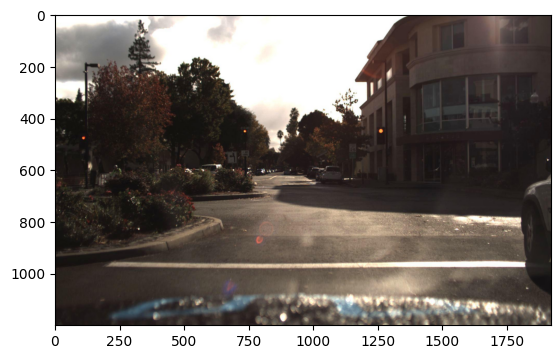

In [ ]:
#plt_image = image.imread('./export/1478899899643423219_jpg.rf.6fac8100c9889ab25c3cc0605cfa04b6.jpg')
plt_image = image.imread('./export/1478020296697349606_jpg.rf.vWUc0iTZE2aUAHRxqaLh.jpg')
#plt_image = image.imread('./export/1478899560868761050_jpg.rf.93f17b56d0e5e226a82d940bff1b4911.jpg')

print(plt_image.dtype)
print(plt_image.shape)

fig, ax = plt.subplots()

ax.imshow(plt_image)

plt.show()

Custom DataSet 1:

In [ ]:
class SelfDrivingCarDataset(torch.utils.data.Dataset):
    def __init__(self, images_path, std=False):
        super(SelfDrivingCarDataset, self).__init__()
        self.images_path = glob.glob(images_path+"*jpg")
        self.std = std
        with open(images_path+'_annotations.coco.json',) as f:
            self.annotations = json.load(f)

    def __len__(self):
        return len(self.images_path)

    def __getitem__(self, idx):
        file_path = self.images_path[idx]
        file_name = file_path.split("/")[2]
        img_id = None
        for img_name in self.annotations['images']:
            if img_name['file_name'] == file_name:
                img_id = img_name['id']

        bbox, areas, iscrowd, labels = [], [], [], []

        for box in self.annotations['annotations']:
            if box['image_id'] == img_id:
                bbox.append(box['bbox'])
                areas.append(box['area'])
                iscrowd.append(box['iscrowd'])
                labels.append(box['category_id'])

        img = cv2.imread(str(file_path), cv2.IMREAD_UNCHANGED)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB).astype(np.float32)
        bbox = np.array(bbox)
        areas = np.array(areas)
        iscrowd = np.array(iscrowd)
        labels = np.array(labels)

        if len(bbox) !=0:
            bbox[:, 2] = bbox[:, 0] + bbox[:, 2]
            bbox[:, 3] = bbox[:, 1] + bbox[:, 3]
            bbox = torch.from_numpy(bbox)
            bbox = torch.as_tensor(bbox, dtype=torch.int64)
        else:
            bbox = torch.zeros((0, 4), dtype=torch.float32)


        if self.std:
            img = img/255.0

        target = {}

        labels = torch.tensor(labels, dtype=torch.int64)
        iscrowd = torch.tensor(iscrowd, dtype=torch.int64)
        image_id = torch.tensor([idx])
        areas = torch.as_tensor(areas.astype(np.float64), dtype=torch.double)

        target["boxes"] = bbox
        target["labels"] = labels
        target["area"] = areas
        target["iscrowd"] = iscrowd
        target["image_id"] = image_id

        img = np.array(img)
        if img.shape[0] != 3:
            img = img.reshape(3, img.shape[0], img.shape[1])

        img = torch.from_numpy(img)
        img = torch.as_tensor(img, dtype=torch.double)

        return img, target

Custom DataSet 2:

In [ ]:
from PIL import Image
import os
import os.path
from typing import Any, Callable, Optional, Tuple, List


class CarDetection(torch.utils.data.Dataset):
    """`MS Coco Detection <https://cocodataset.org/#detection-2016>`_ Dataset.

    Args:
        root (string): Root directory where images are downloaded to.
        annFile (string): Path to json annotation file.
        transform (callable, optional): A function/transform that  takes in an PIL image
            and returns a transformed version. E.g, ``transforms.ToTensor``
        target_transform (callable, optional): A function/transform that takes in the
            target and transforms it.
        transforms (callable, optional): A function/transform that takes input sample and its target as entry
            and returns a transformed version.
    """

    def __init__(
        self,
        root: str,
        annFile: str,
        transform: Optional[Callable] = None,
        target_transform: Optional[Callable] = None,
        transforms: Optional[Callable] = None,
    ):
        # super().__init__(root, transforms, transform, target_transform)
        from pycocotools.coco import COCO

        self.root = root
        self.coco = COCO(annFile)
        self.ids = list(sorted(self.coco.imgs.keys()))
        self.transforms = None

    def _load_image(self, id: int) -> Image.Image:
        path = self.coco.loadImgs(id)[0]["file_name"]
        return Image.open(os.path.join(self.root, path)).convert("RGB")

    def _load_target(self, id) -> List[Any]:
        return self.coco.loadAnns(self.coco.getAnnIds(id))

    def __getitem__(self, index: int) -> Tuple[Any, Any]:
        id = self.ids[index]
        image = self._load_image(id)
        target = self._load_target(id)

        targets = {}
        targets['boxes'] = torch.tensor([item['bbox'] for item in target])#.view(-1, 4)
        targets['labels'] = torch.tensor([item['category_id'] for item in target])#.view(-1)

        if self.transforms is not None:
            image, target = self.transforms(image, target)

        image = torchvision.transforms.functional.to_tensor(image)

        return image, targets

    def __len__(self) -> int:
        return len(self.ids)

Showing a Sample image with Custom DataSet ( img & target [boxes and labels] ):

torch.Size([1200, 1920, 3]) tensor([[   0,  478,  236,  672],
        [ 132,  612,  312,  728],
        [ 216,  504,  482,  666],
        [ 264,  520,  414,  682],
        [ 280,  554,  800,  940],
        [ 586,  440,  888,  754],
        [ 648,  494,  882,  766],
        [ 922,  596, 1018,  674],
        [ 928,  604, 1056,  698],
        [1022,  550, 1206,  712],
        [1090,  564, 1416,  766],
        [1352,  478, 1530,  666]]) tensor([11,  2,  2, 11,  2,  2, 11,  2,  2,  2,  2,  2])


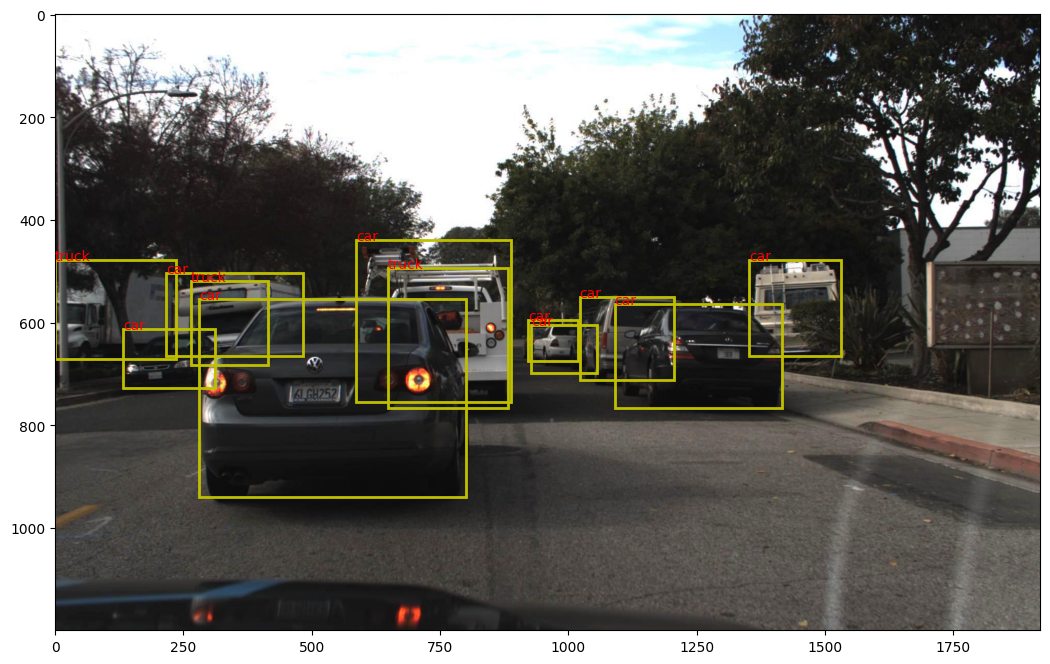

In [ ]:
dataset = SelfDrivingCarDataset("./export/")

img, target = dataset.__getitem__(155)

img = img.reshape(img.shape[1], img.shape[2], 3)
img = torch.as_tensor(img, dtype=torch.int)
print(img.shape, target["boxes"], target["labels"])

fig, ax = plt.subplots(figsize=(16,8))
ax.imshow(img)
for lab, lab_name in zip(target['boxes'], target["labels"]):
    rect = patches.Rectangle((lab[0], lab[1]), lab[2]-lab[0], lab[3]-lab[1],
                             linewidth=2, edgecolor='y', facecolor='none')
    ax.annotate(category_dict[int(lab_name)],(lab[0], lab[1]),
                color='red', fontsize=10,backgroundcolor="none")

    ax.add_patch(rect)

plt.show()


Image Transformations:

 For training `EfficientNetB0CBAM`, the images must be resized and normalized.
 We'll resize all images to `224x224`, which is the input size for EfficientNet, and apply standard ImageNet normalization.


DataLoader Setup:

In [ ]:
def collate_fn(batch):
    return tuple(zip(*batch))

# -------------- Custom DataSet --------------
#train_dataset = SelfDrivingCarDataset("./export/", std=True)
#val_dataset = SelfDrivingCarDataset("./export/", std=True)
#test_dataset = SelfDrivingCarDataset("./export/", std=True)



dataset = SelfDrivingCarDataset("./export/", std=True)
#dataset = CarDetection("./export/", '/content/export/_annotations.coco.json')#, transforms=transform)




# split the dataset in train and test set
indices = torch.randperm(len(dataset)).tolist()

train_dataset = torch.utils.data.Subset(dataset, indices[:18800])
val_dataset = torch.utils.data.Subset(dataset, indices[18800:23800])
test_dataset = torch.utils.data.Subset(dataset, indices[23800:])


# -------------- Data Loader --------------
# define training and validation data loaders
train_dataloader = torch.utils.data.DataLoader(
        train_dataset, batch_size=4, shuffle=True, num_workers=0,
        collate_fn = collate_fn)

val_dataloader = torch.utils.data.DataLoader(
        val_dataset, batch_size=4, shuffle=False, num_workers=0,
        collate_fn = collate_fn)

test_dataloader = torch.utils.data.DataLoader(
        test_dataset, batch_size=1, shuffle=False, num_workers=0,
        collate_fn = collate_fn)

In [ ]:
# ===================================================================

In [ ]:
print('Size of train data: ',len(train_dataset))
print('Size of val data: ',len(val_dataset))
print('Size of test data: ',len(test_dataset))

Size of train data:  18800
Size of val data:  5000
Size of test data:  6200


In [ ]:
#batch = next(iter(trainloader))
batch = next(iter(train_dataloader)) #for this program

In [ ]:
batch[0], batch[1]

In [ ]:
images = [image.to(device) for image in batch[0]]
targets = [{k: v.to(device) for k, v in t.items()} for t in batch[1]]

In [ ]:
images

In [ ]:
targets

In [ ]:
if(torch.cuda.is_available()):
    device = torch.device("cuda")
    print("Device:", device, torch.cuda.get_device_name(0))
else:
    device= torch.device("cpu")
    print("Device:", device)

Device: cuda Tesla T4


In [ ]:
class LossAverager:
    def __init__(self):
        self.reset()

    def reset(self):
        self.val = 0
        self.avg = 0
        self.sum = 0
        self.count = 0

    def update(self, val, n=1):
        self.val = val
        self.sum += val * n
        self.count += n
        self.avg = self.sum / self.count

In [ ]:
# Initialize the custom EfficientNet B0 model with CBAM
#model = EfficientNetB0CBAM(num_classes=11).to(device)
#model = EfficientNetB0(num_classes=11).to(device)

#model.to(device)
# Print the model architecture
#print(model)

In [ ]:
model = torchvision.models.detection.retinanet_resnet50_fpn(True)
model.to(device)

In [ ]:
import torch.optim as optim

# criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(), lr=0.001,
                      momentum=0.9, weight_decay=5e-4)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=20000)

In [ ]:
# ----------------------------------------------------------------------

# Training
def train(epoch):
    model.train()
    #loss_total = AverageMeter()
    # accuracy = torchmetrics.Accuracy().cuda()
    for batch_idx, (inputs, targets) in enumerate(train_dataloader):
        # inputs, targets = inputs.to(device), targets.to(device)
        inputs = [image.to(device) for image in inputs]
        targets = [{k: v.to(device) for k, v in t.items()} for t in targets]
        #print(type(targets))


        optimizer.zero_grad()
        loss_dict = model(inputs, targets)
        loss = sum(loss for loss in loss_dict.values())
        # loss = criterion(outputs, targets)
        loss.backward()
        optimizer.step()
        loss_total.update(loss)
        # accuracy(outputs.softmax(dim=-1), targets)
        # print(targets[:10])
        # if batch_idx == 20:
        #     break
        scheduler.step()
    # acc = accuracy.compute()
    #writer.add_scalar('Loss/train', loss_total.avg.item(), epoch)
    # writer.add_scalar('Acc/train', acc.item(), epoch)
    #logger.info(f'Train: Epoch:{epoch} Loss:{loss_total.avg:.4}')
    # logger.info(f'Train: Epoch:{epoch} Loss:{loss_total.avg:.4} Accuracy:{acc:.4}')

# ----------------------------------------------------------------------

In [ ]:
# writer = SummaryWriter()
#checkpoint = Checkpoint('ckpt-retina-dar-detection')
start, end = 0, 10
for epoch in range(start, end):
    train(epoch)
    # test(epoch, checkpoint)
    #evaluate(net, testloader, device=device)

#writer.close()

RuntimeError: Input type (torch.cuda.DoubleTensor) and weight type (torch.cuda.FloatTensor) should be the same

In [ ]:
#from engine import train_one_epoch, evaluate
import time

loss_hist = LossAverager()

EPOCHS = 2

#model.double()
model.to(device)

#params = [p for p in model.parameters() if p.requires_grad]
optimizer = torch.optim.Adam(params, lr=0.001) #lr=0.00005
lr_scheduler = torch.optim.lr_scheduler.StepLR(optimizer,
                                                   step_size=3,
                                                   gamma=0.1)

Training Loop:

model = EfficientNetB0CBAM(num_classes=11).to(device)




In [ ]:
for epoch in range(EPOCHS):
    print(f"Epoch {epoch+1}/{EPOCHS}")
    tick = time.time()
    model.train()
    loss_hist.reset()

    for images, targets in tqdm(train_dataloader):

        images = torch.stack(images).to(device)
        targets = [{k: v.to(device) for k, v in t.items()} for t in targets]

        print('-------')
        #print(images)
        #print(targets)
        #print(images.shape)
        #print(targets.shape)

        bs = images.shape[0]

        loss_dict = model(images, targets)

        totalLoss = sum(loss for loss in loss_dict.values())
        lossValue = totalLoss.item()
        loss_hist.update(lossValue, bs)

        optimizer.zero_grad()
        totalLoss.backward()
        optimizer.step()
        lr_scheduler.step(totalLoss)

    print(f"Train loss: {loss_hist.avg}")
    loss_hist.reset()

    for images, targets in val_dataloader:
        images = torch.stack(images).to(device)
        targets = [{k: v.to(device) for k, v in t.items()} for t in targets]
        loss_dict = model(images, targets)
        totalLoss = sum(loss for loss in loss_dict.values())
        lossValue = totalLoss.item()
        loss_hist.update(lossValue,bs)

    print(f"Val loss: {loss_hist.avg}")


Epoch 1/2


  0%|          | 0/4700 [00:00<?, ?it/s]

-------


TypeError: EfficientNetB0.forward() takes 2 positional arguments but 3 were given

### 6. JSON File Structure
Here’s an example of how your JSON file should be structured:

```json
[
  {"image": "image1.jpg", "label": 0},
  {"image": "image2.jpg", "label": 3},
  {"image": "image3.jpg", "label": null},  # This example will be filtered out
  ...
]
```

### Key Changes:
- **JSON Annotations**: The dataset class reads the annotations from a JSON file, as requested.
- **Null Examples**: Rows where `label` is `null` are automatically filtered out during the dataset loading process.
- **Data Augmentation**: If you need additional augmentations, such as random flips or rotations, you can easily add them to the `transform` pipeline.

This setup will allow you to train `EfficientNetB0CBAM` on the Udacity Self-Driving Car dataset using the JSON file for annotations.

Output shape: torch.Size([1, 1000])
